# **Predicting Sleep Quality Using LSTM Models on In-Situ Wearable HRV Data**

## **Install Dependencies**

In [2]:
!pip install requests imbalanced-learn tensorflow scikit-learn -q
!pip install pandas numpy matplotlib seaborn joblib -q

## **Import Libraries**

In [3]:
import warnings, os, glob
warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score, f1_score
import tensorflow as tf
from tensorflow.keras.models  import Sequential, Model, model_from_json
from tensorflow.keras.layers  import LSTM, Dense, Dropout, BatchNormalization, Bidirectional, Conv1D
from tensorflow.keras.layers import GlobalAveragePooling1D, Input, LayerNormalization, MultiHeadAttention
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks  import ModelCheckpoint, EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.utils   import to_categorical
from imblearn.over_sampling   import SMOTE
import joblib, json

print("TensorFlow :", tf.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## **Download Dataset**

In [1]:
import os, requests

DATA_DIR = "hrv_sleep_dataset"
os.makedirs(DATA_DIR, exist_ok=True)


API = "https://api.figshare.com/v2/articles/28509740/files"
all_files = requests.get(API, timeout=30).json()

print("Files available on Figshare:")
for f in all_files:
    print(f"  [{f['id']}]  {f['name']:<45}  {f['size']/1e6:>8.1f} MB")


WANT_KEYWORDS = ['sensor_hrv_filtered', 'sleep_diary', 'survey']

for f in all_files:
    name = f['name']
    if not any(kw in name for kw in WANT_KEYWORDS):
        continue
    dest = os.path.join(DATA_DIR, name)
    if os.path.exists(dest):
        print(f"✓ already exists: {name}")
        continue
    size_mb = f['size'] / 1e6
    print(f"↓ Downloading {name}  ({size_mb:.1f} MB) ...", end="", flush=True)
    r = requests.get(f['download_url'], stream=True, timeout=300)
    r.raise_for_status()
    with open(dest, 'wb') as fh:
        for chunk in r.iter_content(chunk_size=512 * 1024):
            fh.write(chunk)
    print(f"  done  ({os.path.getsize(dest)/1e6:.1f} MB saved)")

print("\n=== Files in DATA_DIR ===")
for fname in sorted(os.listdir(DATA_DIR)):
    fpath = os.path.join(DATA_DIR, fname)
    print(f"  {fname:<45}  {os.path.getsize(fpath)/1e6:>8.1f} MB")


Files available on Figshare:
  [52669385]  sensor_hrv_filtered.csv                            17.3 MB
  [52669388]  README.docx                                         0.0 MB
  [52669391]  sensor_hrv.csv                                     35.3 MB
  [52669394]  survey.csv                                          0.0 MB
  [52669397]  sleep_diary.csv                                     0.1 MB
  [52672928]  raw_data.zip                                    19740.5 MB
✓ already exists: sensor_hrv_filtered.csv
✓ already exists: survey.csv
✓ already exists: sleep_diary.csv

=== Files in DATA_DIR ===
  sensor_hrv_filtered.csv                            17.3 MB
  sleep_diary.csv                                     0.1 MB
  survey.csv                                          0.0 MB


## **Loading Raw Files**

In [4]:
DATA_DIR = "hrv_sleep_dataset"

def find_csv(keyword, search_dir=DATA_DIR):
    """Find a CSV whose filename contains 'keyword' (case-insensitive)."""
    all_csv = glob.glob(f"{search_dir}/**/*.csv", recursive=True) + \
              glob.glob(f"{search_dir}/*.csv")
    matches = [p for p in all_csv if keyword.lower() in os.path.basename(p).lower()]
    if not matches:
        raise FileNotFoundError(
            f"No CSV containing '{keyword}' found under {search_dir}/\n"
            f"Files present: {os.listdir(search_dir)}")
    return matches[0]

sensor_path = find_csv("sensor_hrv_filtered")
sleep_path  = find_csv("sleep_diary")
survey_path = find_csv("survey")

print("sensor_hrv_filtered :", sensor_path)
print("sleep_dairy         :", sleep_path)
print("survey              :", survey_path)

sensor_hrv_filtered : hrv_sleep_dataset/sensor_hrv_filtered.csv
sleep_dairy         : hrv_sleep_dataset/sleep_diary.csv
survey              : hrv_sleep_dataset/survey.csv


In [5]:
sensor_df = pd.read_csv(sensor_path)
sleep_df  = pd.read_csv(sleep_path)
survey_df = pd.read_csv(survey_path)

info = [("sensor_hrv_filtered", sensor_df),("sleep_daily", sleep_df),("survey", survey_df)]

for name, df in info:
    print(f"\n── {name} ──")
    print(f"  shape  : {df.shape}")
    print(f"  columns: {df.columns.tolist()}")
    print(df.head(2).to_string())


── sensor_hrv_filtered ──
  shape  : (38913, 28)
  columns: ['deviceId', 'ts_start', 'ts_end', 'missingness_score', 'HR', 'ibi', 'acc_x_avg', 'acc_y_avg', 'acc_z_avg', 'grv_x_avg', 'grv_y_avg', 'grv_z_avg', 'grv_w_avg', 'gyr_x_avg', 'gyr_y_avg', 'gyr_z_avg', 'steps', 'distance', 'calories', 'light_avg', 'sdnn', 'sdsd', 'rmssd', 'pnn20', 'pnn50', 'lf', 'hf', 'lf/hf']
  deviceId       ts_start         ts_end  missingness_score         HR         ibi  acc_x_avg  acc_y_avg  acc_z_avg  grv_x_avg  grv_y_avg  grv_z_avg  grv_w_avg  gyr_x_avg  gyr_y_avg  gyr_z_avg  steps  distance  calories   light_avg        sdnn       sdsd       rmssd     pnn20     pnn50           lf           hf     lf/hf
0     ab60  1617262425031  1617262724833           0.295448  84.592816  728.534374   0.284765  -0.593973   9.195984  -0.094203   0.134908   0.001618   0.026770  -1.037209   0.768969   0.002483    0.0    0.0000  0.000000  841.324415   89.363225  78.033038   98.417649  0.746269  0.391791  1818.065625  1252.9

## **Info about data**

#### **Auto-Detect Key Columns**

In [7]:
def pick_col(df, *keywords, required=True):
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    if required:
        raise KeyError(f"None of {keywords} found in columns: {df.columns.tolist()}")
    return None

S_DEV  = pick_col(sensor_df, 'deviceid', 'device_id', 'device', 'user', 'id')
S_TS   = pick_col(sensor_df, 'ts_start', 'timestamp', 'time', 'start')
S_MISS = pick_col(sensor_df, 'missingness', 'miss', required=False)

D_DEV  = pick_col(sleep_df, 'userid', 'deviceid', 'device_id', 'device', 'user', 'id')
D_DATE = pick_col(sleep_df, 'date', 'day', 'night', 'time')
D_QUAL = pick_col(sleep_df, 'sleep_efficiency', 'efficiency',
                             'quality', 'rating', 'score')

print(f"sensor → device='{S_DEV}'  ts='{S_TS}'  missingness='{S_MISS}'")
print(f"sleep  → device='{D_DEV}'  date='{D_DATE}'  quality='{D_QUAL}'")
print(f"Sleep quality values : {sleep_df[D_QUAL].dropna().unique()[:10]}")
print(f"Sleep quality range  : {sleep_df[D_QUAL].min():.2f} – {sleep_df[D_QUAL].max():.2f}")

sensor → device='deviceId'  ts='ts_start'  missingness='missingness_score'
sleep  → device='userId'  date='date'  quality='sleep_efficiency'
Sleep quality values : [0.86666667 0.91489362 0.93023256 0.93181818 0.94736842 0.94545455
 0.84615385 0.92307692 0.91891892 0.925     ]
Sleep quality range  : 0.47 – 1.00


## **Merge Sensor + Sleep Diary & Feature Engineering**

In [8]:
sensor_df['_ts_dt'] = pd.to_datetime(sensor_df[S_TS], unit='ms', utc=True, errors='coerce')
if sensor_df['_ts_dt'].isna().all():

    sensor_df['_ts_dt'] = pd.to_datetime(sensor_df[S_TS], unit='s', utc=True, errors='coerce')
if sensor_df['_ts_dt'].isna().all():

    sensor_df['_ts_dt'] = pd.to_datetime(sensor_df[S_TS], utc=True, errors='coerce')

sensor_df['_date'] = sensor_df['_ts_dt'].dt.date


hour = sensor_df['_ts_dt'].dt.hour
night_mask = (hour >= 22) | (hour < 8)
sensor_night = sensor_df[night_mask].copy()
print(f"Total sensor rows   : {len(sensor_df):,}")
print(f"Night-window rows   : {len(sensor_night):,}")


SKIP_COLS = {S_DEV, S_TS, '_ts_dt', '_date', S_MISS or '__none__',
             'ts_end', 'ts_start', 'ts_start_dt'}
HRV_COLS  = [c for c in sensor_night.select_dtypes(include=np.number).columns
             if c not in SKIP_COLS]
print(f"HRV/sensor feature cols ({len(HRV_COLS)}): {HRV_COLS}")


agg_dict = {c: ['mean', 'std'] for c in HRV_COLS}
agg_df   = (sensor_night
            .groupby([S_DEV, '_date'])
            .agg(agg_dict)
            .reset_index())
agg_df.columns = ([S_DEV, '_date'] +
                  [f"{c}_{s}" for c, s in agg_df.columns[2:]])
agg_df['_date'] = pd.to_datetime(agg_df['_date'])
print(f"\nAggregated shape: {agg_df.shape}")
agg_df.head(2)

Total sensor rows   : 38,913
Night-window rows   : 19,940
HRV/sensor feature cols (24): ['HR', 'ibi', 'acc_x_avg', 'acc_y_avg', 'acc_z_avg', 'grv_x_avg', 'grv_y_avg', 'grv_z_avg', 'grv_w_avg', 'gyr_x_avg', 'gyr_y_avg', 'gyr_z_avg', 'steps', 'distance', 'calories', 'light_avg', 'sdnn', 'sdsd', 'rmssd', 'pnn20', 'pnn50', 'lf', 'hf', 'lf/hf']

Aggregated shape: (1207, 50)


,deviceId,_date,HR_mean,HR_std,ibi_mean,ibi_std,acc_x_avg_mean,acc_x_avg_std,acc_y_avg_mean,acc_y_avg_std,...,pnn20_mean,pnn20_std,pnn50_mean,pnn50_std,lf_mean,lf_std,hf_mean,hf_std,lf/hf_mean,lf/hf_std
0,ab60,2021-03-04,83.011676,3.52113,745.115141,34.499344,3.357308,1.978160,-2.568504,1.549276,...,0.747200,0.034968,0.436040,0.058196,1990.163520,1029.474088,1927.204590,806.566954,1.111618,0.591013
1,ab60,2021-03-08,79.671746,7.04852,760.390785,61.199220,2.253395,1.855812,-4.309280,1.786049,...,0.707022,0.050120,0.384152,0.074280,1625.112098,757.812742,1819.608881,991.975247,1.128015,0.626979


In [9]:
sleep_df[D_DATE] = pd.to_datetime(sleep_df[D_DATE], errors='coerce')
sleep_df = sleep_df.dropna(subset=[D_QUAL]).copy()

sleep_clean = sleep_df.rename(columns={D_DEV: S_DEV, D_DATE: '_date'})


merged = agg_df.merge(sleep_clean[[S_DEV, '_date', D_QUAL] +
                                   [c for c in sleep_clean.columns
                                    if c not in [S_DEV, '_date', D_QUAL]]],
                      on=[S_DEV, '_date'], how='inner')
print(f"Merged shape          : {merged.shape}")
print(f"Unique participants   : {merged[S_DEV].nunique()}")
print(f"Date range            : {merged['_date'].min()} → {merged['_date'].max()}")


SV_DEV = pick_col(survey_df, 'deviceid', 'device_id', 'device', 'user', 'id')
survey_df = survey_df.rename(columns={SV_DEV: S_DEV})
survey_first = survey_df.groupby(S_DEV).first().reset_index()
merged = merged.merge(survey_first, on=S_DEV, how='left', suffixes=('', '_sv'))
print(f"After survey merge    : {merged.shape}")

Merged shape          : (1109, 59)
Unique participants   : 49
Date range            : 2021-03-09 00:00:00 → 2021-04-05 00:00:00
After survey merge    : (1109, 81)


In [10]:
q_min = sleep_df[D_QUAL].min()
q_max = sleep_df[D_QUAL].max()

def label_quality(q):
    if pd.isna(q): return None
    q_norm = (q - q_min) / (q_max - q_min + 1e-9)
    if   q_norm <= 0.40: return 'Poor'
    elif q_norm <= 0.70: return 'Fair'
    else:                return 'Good'

merged['sleep_quality_class'] = merged[D_QUAL].apply(label_quality)
merged = merged.dropna(subset=['sleep_quality_class']).reset_index(drop=True)

print("Class distribution:")
print(merged['sleep_quality_class'].value_counts())

Class distribution:
sleep_quality_class
Good    1021
Fair      73
Poor      15
Name: count, dtype: int64


In [11]:
EXCLUDE = {S_DEV, '_date', D_QUAL, 'sleep_quality_class'}


if 'lf_mean' in merged.columns and 'hf_mean' in merged.columns:
    merged['lf_hf_ratio'] = merged['lf_mean'] / (merged['hf_mean'] + 1e-9)


if 'rmssd_mean' in merged.columns and 'sdnn_mean' in merged.columns:
    merged['rmssd_sdnn_ratio'] = merged['rmssd_mean'] / (merged['sdnn_mean'] + 1e-9)

FEATURE_COLS = [c for c in merged.select_dtypes(include=np.number).columns
                if c not in EXCLUDE and 'date' not in c.lower()
                and 'ts_' not in c.lower()]


for c in FEATURE_COLS:
    merged[c] = merged[c].fillna(merged[c].median())

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"Remaining NaN: {merged[FEATURE_COLS].isnull().sum().sum()}")

Features (77): ['HR_mean', 'HR_std', 'ibi_mean', 'ibi_std', 'acc_x_avg_mean', 'acc_x_avg_std', 'acc_y_avg_mean', 'acc_y_avg_std', 'acc_z_avg_mean', 'acc_z_avg_std', 'grv_x_avg_mean', 'grv_x_avg_std', 'grv_y_avg_mean', 'grv_y_avg_std', 'grv_z_avg_mean', 'grv_z_avg_std', 'grv_w_avg_mean', 'grv_w_avg_std', 'gyr_x_avg_mean', 'gyr_x_avg_std', 'gyr_y_avg_mean', 'gyr_y_avg_std', 'gyr_z_avg_mean', 'gyr_z_avg_std', 'steps_mean', 'steps_std', 'distance_mean', 'distance_std', 'calories_mean', 'calories_std', 'light_avg_mean', 'light_avg_std', 'sdnn_mean', 'sdnn_std', 'sdsd_mean', 'sdsd_std', 'rmssd_mean', 'rmssd_std', 'pnn20_mean', 'pnn20_std', 'pnn50_mean', 'pnn50_std', 'lf_mean', 'lf_std', 'hf_mean', 'hf_std', 'lf/hf_mean', 'lf/hf_std', 'wakeup@night', 'waso', 'sleep_duration', 'in_bed_duration', 'sleep_latency', 'sex', 'age', 'marriage', 'occupation', 'smartwatch', 'regular', 'exercise', 'coffee', 'smoking', 'drinking', 'height', 'weight', 'ISI_1', 'PHQ9_1', 'GAD7_1', 'MEQ', 'ISI_2', 'PHQ9_2',

## Final Dataset

In [60]:
merged.head()

,deviceId,_date,HR_mean,HR_std,ibi_mean,ibi_std,acc_x_avg_mean,acc_x_avg_std,acc_y_avg_mean,acc_y_avg_std,...,ISI_2,PHQ9_2,GAD7_2,ISI_F,PHQ9_F,GAD7_F,sleep_quality_class,lf_hf_ratio,rmssd_sdnn_ratio,label
0,ab60,2021-03-09,89.438517,3.998462,690.086484,33.776038,2.620106,0.789128,-6.483442,2.466247,...,3.0,0.0,0.0,2.0,0.0,0.0,Good,1.499882,0.926379,1
1,ab60,2021-03-10,98.071496,13.584652,631.672791,89.926008,2.661089,0.852284,1.192467,3.893900,...,3.0,0.0,0.0,2.0,0.0,0.0,Good,1.093789,1.044707,1
2,ab60,2021-03-11,88.181814,6.796192,701.976489,60.073451,3.041514,1.902570,-2.419738,2.546038,...,3.0,0.0,0.0,2.0,0.0,0.0,Good,0.456042,0.966464,1
3,ab60,2021-03-12,78.544272,6.494832,775.930755,67.283401,2.911341,1.891831,-2.306368,2.660854,...,3.0,0.0,0.0,2.0,0.0,0.0,Good,1.078885,0.920186,1
4,ab60,2021-03-13,99.612453,7.867809,622.139763,48.387791,2.864789,1.880330,-1.576133,2.810737,...,3.0,0.0,0.0,2.0,0.0,0.0,Good,1.266411,1.017904,1


## **Data Cleaning**

In [61]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1109 entries, 0 to 1108
Data columns (total 85 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   deviceId             1109 non-null   object        
 1   _date                1109 non-null   datetime64[ns]
 2   HR_mean              1109 non-null   float64       
 3   HR_std               1109 non-null   float64       
 4   ibi_mean             1109 non-null   float64       
 5   ibi_std              1109 non-null   float64       
 6   acc_x_avg_mean       1109 non-null   float64       
 7   acc_x_avg_std        1109 non-null   float64       
 8   acc_y_avg_mean       1109 non-null   float64       
 9   acc_y_avg_std        1109 non-null   float64       
 10  acc_z_avg_mean       1109 non-null   float64       
 11  acc_z_avg_std        1109 non-null   float64       
 12  grv_x_avg_mean       1109 non-null   float64       
 13  grv_x_avg_std        1109 non-nul

In [64]:
merged.shape

(1109, 85)

## Remove Duplicates

In [65]:
merged = merged.drop_duplicates()

## Remove Null Values

In [66]:
merged = merged.dropna()

## **Exploratory Data Analysis**

#### **Sleep Quality Distribution**

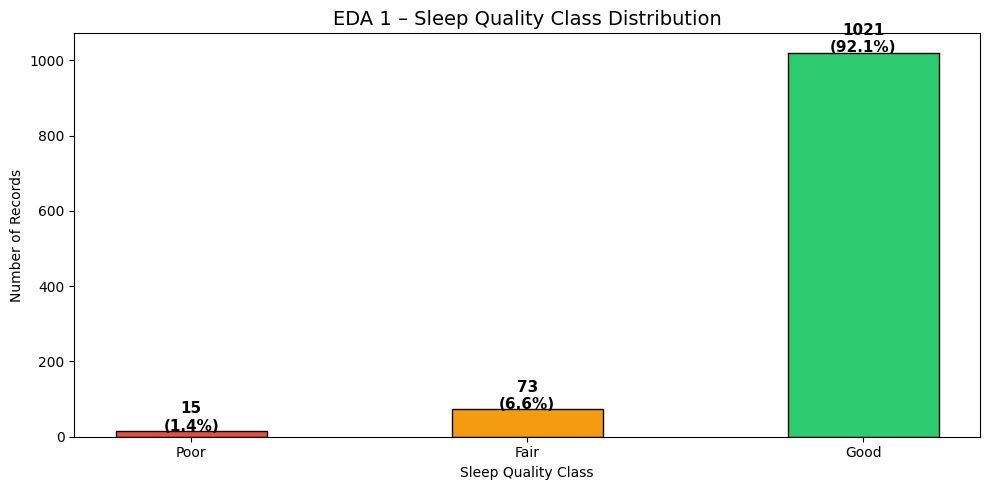

sleep_quality_class
Good    1021
Fair      73
Poor      15
Name: count, dtype: int64


In [12]:
quality_counts = merged['sleep_quality_class'].value_counts()
colors_eda1    = ['#e74c3c', '#f39c12', '#2ecc71']
ORDER          = ['Poor', 'Fair', 'Good']
ordered_counts = [quality_counts.get(c, 0) for c in ORDER]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ORDER, ordered_counts,
              color=colors_eda1, edgecolor='black', width=0.45)
for bar, cnt in zip(bars, ordered_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{cnt}\n({cnt/len(merged)*100:.1f}%)',
            ha='center', fontsize=11, fontweight='bold')
ax.set_title('EDA 1 – Sleep Quality Class Distribution', fontsize=14)
ax.set_xlabel('Sleep Quality Class'); ax.set_ylabel('Number of Records')
plt.tight_layout(); plt.show()
print(quality_counts)

#### **HRV Feature Distributions per Sleep Quality Class**

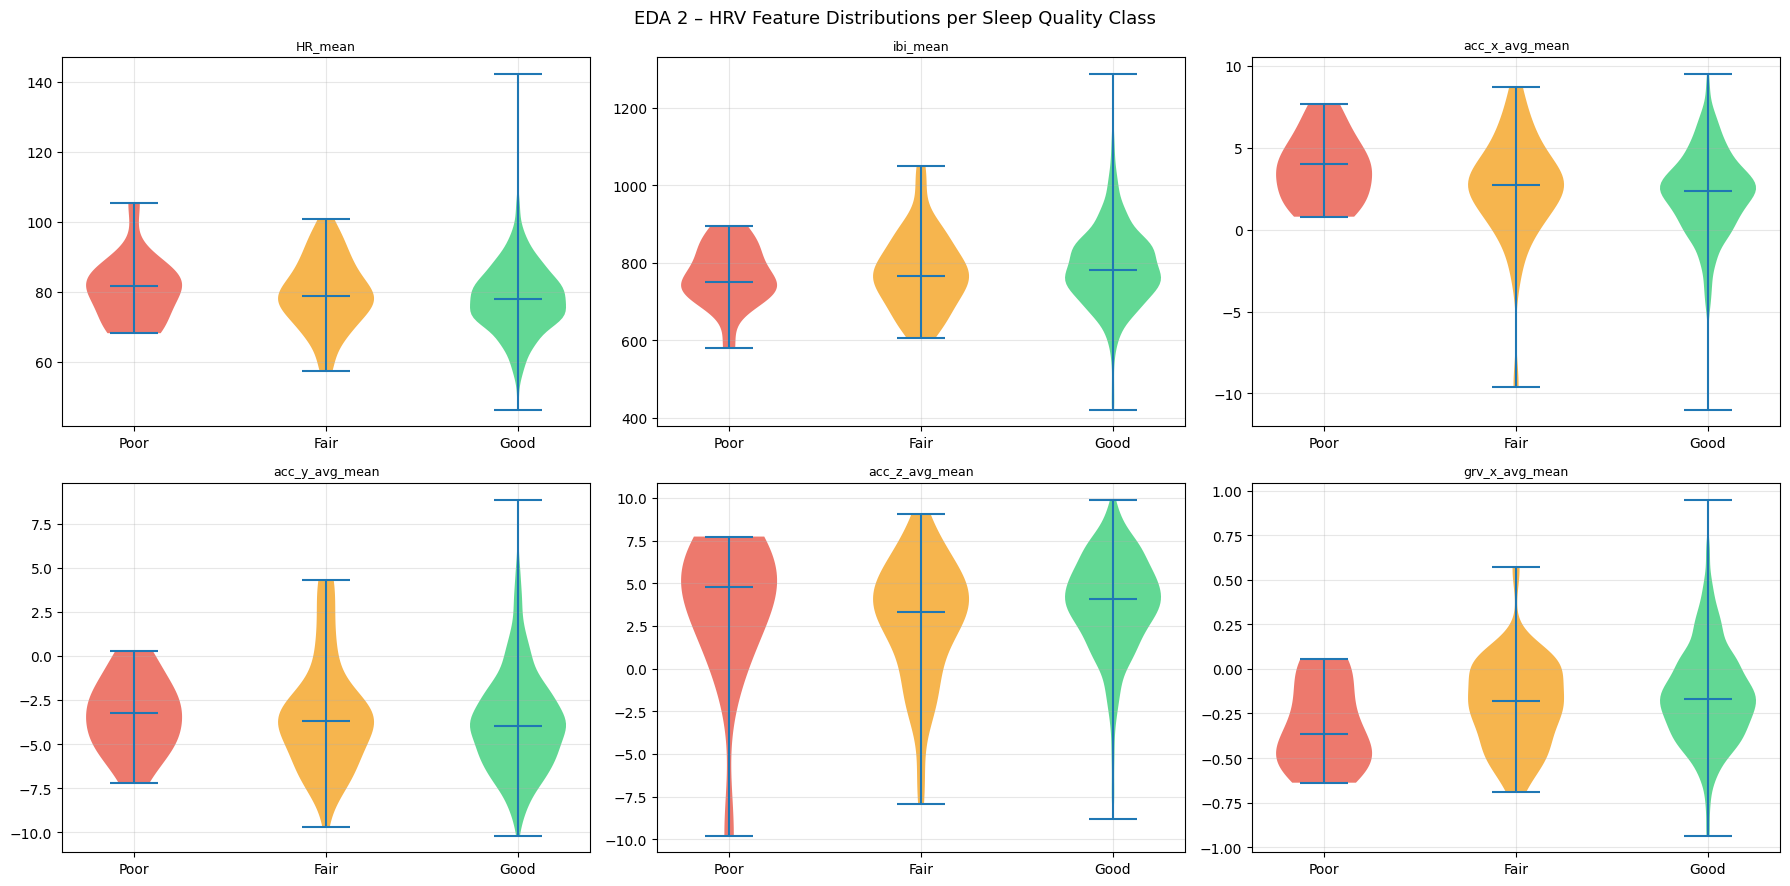

In [13]:
plot_feats = [c for c in FEATURE_COLS if c.endswith('_mean')][:6]
if not plot_feats:
    plot_feats = FEATURE_COLS[:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
colors_v   = {'Poor': '#e74c3c', 'Fair': '#f39c12', 'Good': '#2ecc71'}
for ax, feat in zip(axes.ravel(), plot_feats):
    data_list = [merged[merged['sleep_quality_class'] == q][feat].dropna().values
                 for q in ORDER]
    parts = ax.violinplot(data_list, positions=[1, 2, 3], showmedians=True)
    for pc, color in zip(parts['bodies'], colors_eda1):
        pc.set_facecolor(color); pc.set_alpha(0.75)
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(ORDER)
    ax.set_title(feat, fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle('EDA 2 – HRV Feature Distributions per Sleep Quality Class', fontsize=13)
plt.tight_layout(); plt.show()

#### **Feature Correlation Matrix**

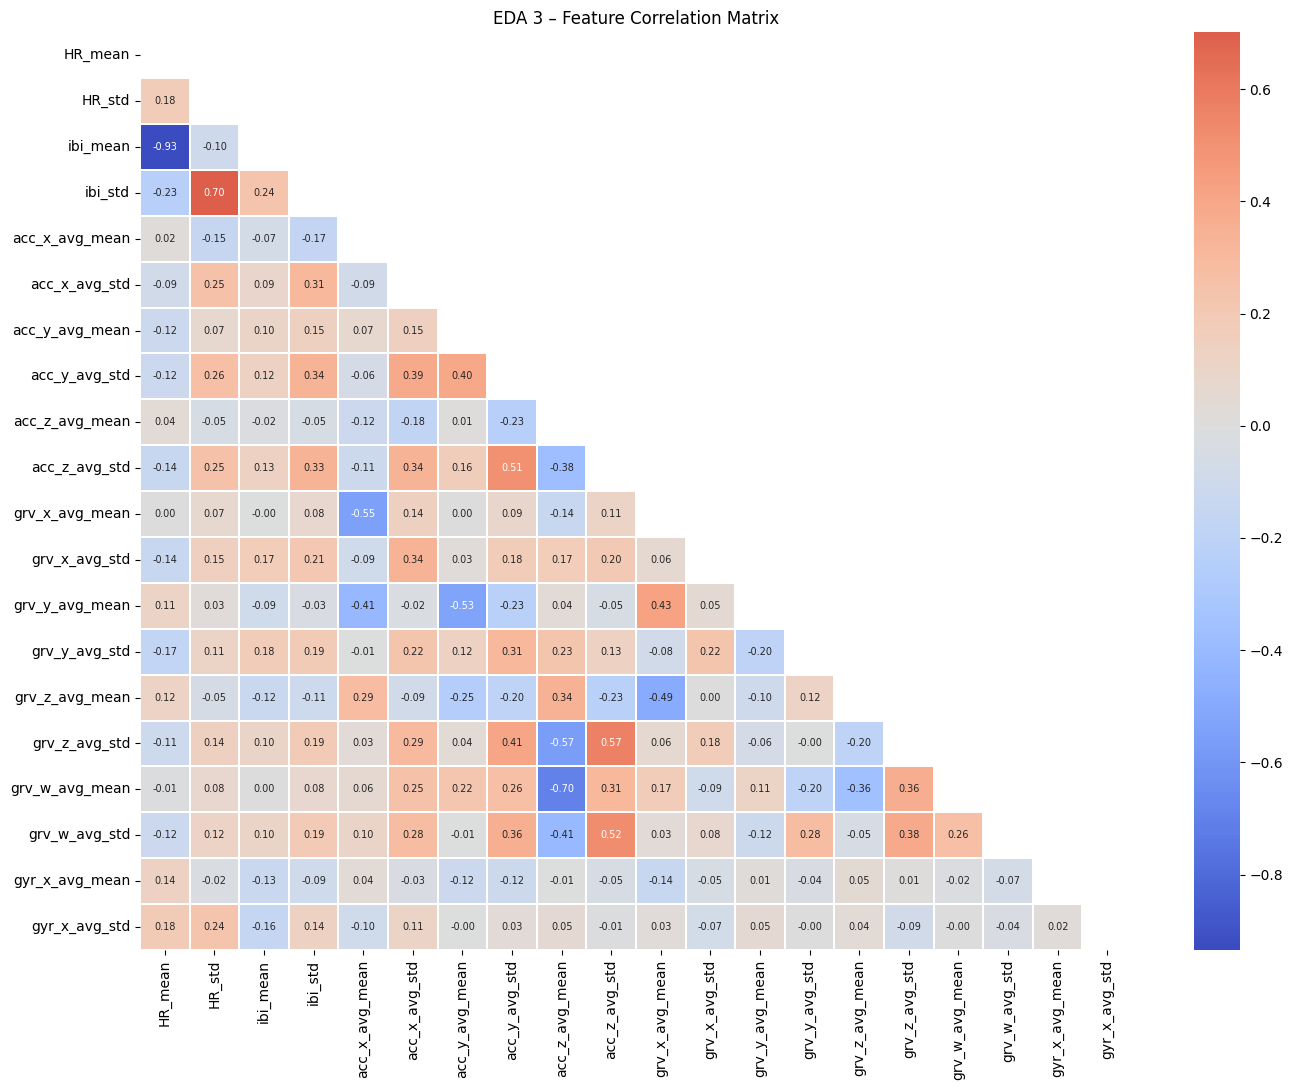

High-correlation pairs (|r|>0.9): [('HR_mean', 'ibi_mean')]


In [14]:
corr_cols = FEATURE_COLS[:20]
corr = merged[corr_cols].corr()
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.3,
            annot_kws={'size': 7}, ax=ax)
ax.set_title('EDA 3 – Feature Correlation Matrix', fontsize=12)
plt.tight_layout(); plt.show()

high_corr = [(corr.columns[i], corr.columns[j])
             for i in range(len(corr)) for j in range(i+1, len(corr))
             if abs(corr.iloc[i, j]) > 0.9]
print(f"High-correlation pairs (|r|>0.9): {high_corr if high_corr else 'None ✓'}")

#### **Statistical Summary Table per Sleep Class**

In [15]:
from scipy import stats as sp_stats

top_feats = [c for c in FEATURE_COLS if c.endswith('_mean')][:8]
if not top_feats:
    top_feats = FEATURE_COLS[:8]

rows = []
for feat in top_feats:
    row = {'Feature': feat}
    group_vals = []
    for cls in ORDER:
        vals = merged[merged['sleep_quality_class'] == cls][feat].dropna()
        row[cls] = f"{vals.mean():.3f} ± {vals.std():.3f}"
        group_vals.append(vals.values)
    f_stat, p_val = sp_stats.f_oneway(*group_vals)
    row['F-stat'] = f'{f_stat:.2f}'; row['p-value'] = f'{p_val:.4f}'
    row['Sig.'] = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else
                  ('*' if p_val < 0.05 else 'ns'))
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Feature')
print("EDA 4 – Statistical Summary (Mean ± Std) + One-Way ANOVA\n")
print(summary_df.to_string())

EDA 4 – Statistical Summary (Mean ± Std) + One-Way ANOVA

                            Poor              Fair               Good F-stat p-value Sig.
Feature                                                                                  
HR_mean           80.479 ± 9.585    79.529 ± 9.965    78.173 ± 10.295   0.94  0.3911   ns
ibi_mean        765.799 ± 79.617  776.475 ± 98.980  789.826 ± 108.112   0.87  0.4182   ns
acc_x_avg_mean     3.706 ± 2.098     2.593 ± 3.199      2.258 ± 2.548   2.81  0.0606   ns
acc_y_avg_mean    -3.363 ± 2.115    -3.308 ± 3.141     -3.711 ± 2.894   0.74  0.4754   ns
acc_z_avg_mean     3.587 ± 4.401     2.851 ± 3.539      3.792 ± 2.929   3.38  0.0343    *
grv_x_avg_mean    -0.322 ± 0.235    -0.194 ± 0.251     -0.151 ± 0.275   3.67  0.0257    *
grv_y_avg_mean     0.033 ± 0.183     0.113 ± 0.272      0.099 ± 0.251   0.62  0.5378   ns
grv_z_avg_mean     0.085 ± 0.158    -0.026 ± 0.171      0.026 ± 0.149   5.35  0.0048   **


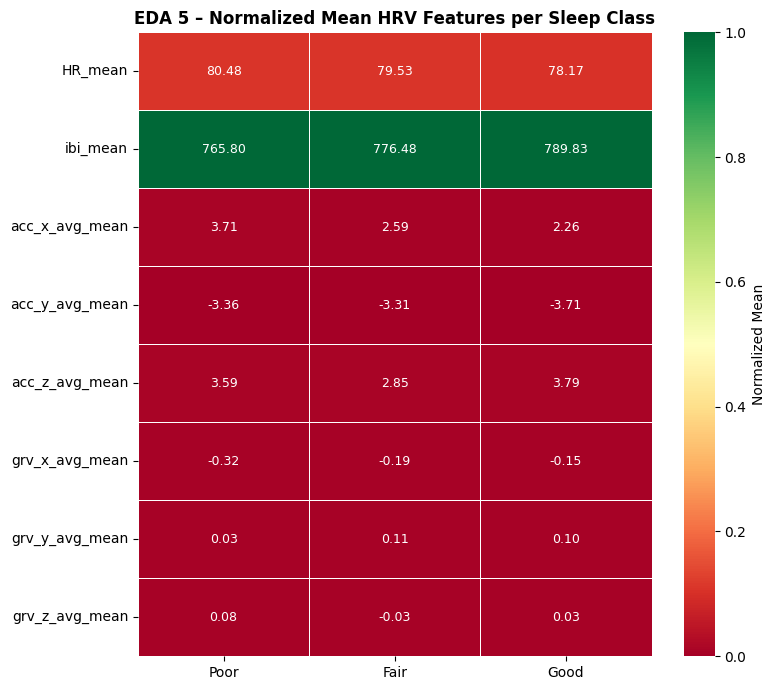

In [16]:
means_df = pd.DataFrame({
    cls: [merged[merged['sleep_quality_class'] == cls][f].mean() for f in top_feats]
    for cls in ORDER}, index=top_feats)

fig, ax = plt.subplots(figsize=(8, 7))
means_norm = (means_df - means_df.min()) / (means_df.max() - means_df.min() + 1e-9)
sns.heatmap(means_norm, annot=means_df.round(2), fmt='.2f',
            cmap='RdYlGn', ax=ax, linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'label': 'Normalized Mean'})
ax.set_title('EDA 5 – Normalized Mean HRV Features per Sleep Class',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

## Class Labeling

In [17]:
le_target = LabelEncoder()
merged['label'] = le_target.fit_transform(merged['sleep_quality_class'])
CLASS_NAMES = list(le_target.classes_)
N_CLASSES   = len(CLASS_NAMES)
print("Classes:", {i: c for i, c in enumerate(CLASS_NAMES)})


Classes: {0: 'Fair', 1: 'Good', 2: 'Poor'}


In [18]:
TIMESTEPS = 7   # 7-night look-back

X_seqs, y_seqs = [], []
for pid, grp in merged.sort_values([S_DEV, '_date']).groupby(S_DEV):
    feat_arr  = grp[FEATURE_COLS].values.astype(np.float32)
    label_arr = grp['label'].values
    for i in range(len(feat_arr) - TIMESTEPS):
        X_seqs.append(feat_arr[i: i + TIMESTEPS])
        y_seqs.append(label_arr[i + TIMESTEPS])

X_seqs = np.array(X_seqs, dtype=np.float32)   # (N, TIMESTEPS, F)
y_seqs = np.array(y_seqs)

F = X_seqs.shape[2]
print(f"Sequences : X={X_seqs.shape}  y={y_seqs.shape}")
print(f"Class dist: {dict(zip(*np.unique(y_seqs, return_counts=True)))}")


Sequences : X=(766, 7, 77)  y=(766,)
Class dist: {np.int64(0): np.int64(50), np.int64(1): np.int64(706), np.int64(2): np.int64(10)}


## **Train / Val / Test split (70 / 15 / 15)**

In [19]:
X_seqs = np.nan_to_num(X_seqs, nan=0.0, posinf=np.finfo(X_seqs.dtype).max, neginf=np.finfo(X_seqs.dtype).min)

X_temp, X_test, y_temp, y_test_raw = train_test_split(
    X_seqs, y_seqs, test_size=0.15, random_state=42, stratify=y_seqs)
X_train_raw, X_val_raw, y_train_raw, y_val_raw = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp)

y_train = to_categorical(y_train_raw, num_classes=N_CLASSES)
y_val   = to_categorical(y_val_raw,   num_classes=N_CLASSES)

## Standard Scaling

In [20]:
scaler = StandardScaler()
X_train_2d = scaler.fit_transform(X_train_raw.reshape(-1, F))
X_val_2d   = scaler.transform(X_val_raw.reshape(-1, F))
X_test_2d  = scaler.transform(X_test.reshape(-1, F))

X_train_raw = X_train_2d.reshape(-1, TIMESTEPS, F)
X_val_raw   = X_val_2d.reshape(-1, TIMESTEPS, F)
X_test      = X_test_2d.reshape(-1, TIMESTEPS, F)

## SMOTE for Class Imbalance

In [21]:
smote = SMOTE(random_state=42)
X_tr_flat, y_train_raw = smote.fit_resample(
    X_train_raw.reshape(len(X_train_raw), -1), y_train_raw)
X_train = X_tr_flat.reshape(-1, TIMESTEPS, F)

In [22]:
y_train = to_categorical(y_train_raw, num_classes=N_CLASSES)
y_val   = to_categorical(y_val_raw,   num_classes=N_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=N_CLASSES)

print(f"X_train : {X_train.shape}  y_train : {y_train.shape}")
print(f"X_val   : {X_val_raw.shape}    y_val   : {y_val.shape}")
print(f"X_test  : {X_test.shape}   y_test  : {y_test.shape}")
print(f"LSTM input shape: (TIMESTEPS={TIMESTEPS}, features={F})")

X_train : (1482, 7, 77)  y_train : (1482, 3)
X_val   : (115, 7, 77)    y_val   : (115, 3)
X_test  : (115, 7, 77)   y_test  : (115, 3)
LSTM input shape: (TIMESTEPS=7, features=77)


### Normalisation check

In [23]:
for name, arr in [('X_train', X_train), ('X_val', X_val_raw), ('X_test', X_test)]:
    flat = arr.reshape(-1, arr.shape[-1])
    print(f"{name}: mean≈{flat.mean():.4f}  std≈{flat.std():.4f}  "
          f"min={flat.min():.3f}  max={flat.max():.3f}  shape={arr.shape}")


X_train: mean≈0.0249  std≈0.9203  min=-16.702  max=43.301  shape=(1482, 7, 77)
X_val: mean≈-0.0051  std≈0.9333  min=-6.882  max=11.864  shape=(115, 7, 77)
X_test: mean≈0.0051  std≈1.0293  min=-16.702  max=43.301  shape=(115, 7, 77)


### Class balance after SMOTE

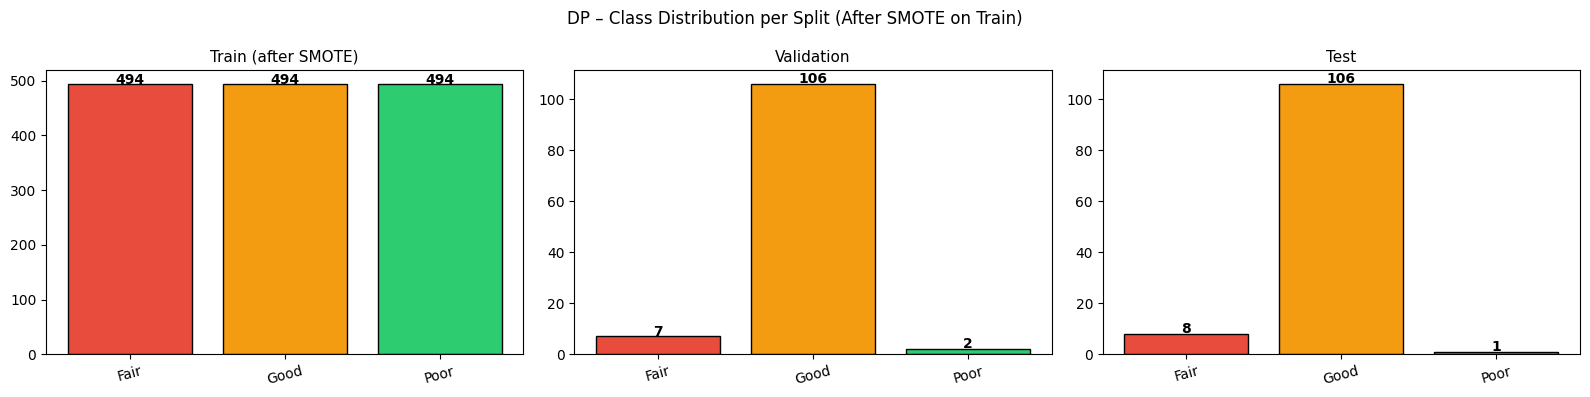

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, y_arr) in zip(axes, [('Train (after SMOTE)', y_train),
                                     ('Validation',          y_val),
                                     ('Test',                y_test)]):
    y_idx = np.argmax(y_arr, axis=1)
    unique, counts = np.unique(y_idx, return_counts=True)
    bars = ax.bar([CLASS_NAMES[u] for u in unique], counts,
                  color=[colors_eda1[u % len(colors_eda1)] for u in unique],
                  edgecolor='black')
    ax.set_title(name, fontsize=11); ax.tick_params(axis='x', rotation=15)
    for i, (u, c) in enumerate(zip(unique, counts)):
        ax.text(i, c + 0.3, str(c), ha='center', fontsize=10, fontweight='bold')
plt.suptitle('DP – Class Distribution per Split (After SMOTE on Train)', fontsize=12)
plt.tight_layout(); plt.show()


## **Model Building**

In [25]:
def loss_plot(history, title=''):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['accuracy'],     label='Train', color='#2ecc71')
    axes[0].plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
    axes[0].set_title(f'Accuracy {title}'); axes[0].legend()
    axes[1].plot(history.history['loss'],     label='Train', color='#2ecc71')
    axes[1].plot(history.history['val_loss'], label='Val',   color='#e74c3c')
    axes[1].set_title(f'Loss {title}'); axes[1].legend()
    plt.tight_layout(); plt.show()

def conf_mat(y_true_oh, y_pred_arr, labels):
    cm = pd.DataFrame(
        confusion_matrix(np.argmax(y_true_oh, axis=1), y_pred_arr),
        columns=labels, index=labels)
    cm.index.name = 'Actual'; cm.columns.name = 'Predicted'
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, cbar=False, cmap='Blues', annot=True,
                annot_kws={'size': 14}, fmt='g')
    plt.title('Confusion Matrix', fontsize=14)
    plt.tight_layout(); plt.show()

def get_callbacks(fname):
    return [
        EarlyStopping(monitor='val_accuracy', patience=15,
                      restore_best_weights=True, verbose=1),
        ModelCheckpoint(fname, monitor='val_accuracy',
                        save_best_only=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0)
    ]

## **Bi-LSTM Model**

In [26]:
def bilstm_model():
    m = Sequential(name='BiLSTM')
    m.add(Bidirectional(LSTM(128, return_sequences=True),
                        input_shape=(TIMESTEPS, F), name='bilstm_1'))
    m.add(BatchNormalization()); m.add(Dropout(0.3))
    m.add(Bidirectional(LSTM(64, return_sequences=False), name='bilstm_2'))
    m.add(BatchNormalization()); m.add(Dropout(0.3))
    m.add(Dense(64, activation='relu')); m.add(Dropout(0.2))
    m.add(Dense(N_CLASSES, activation='softmax'))
    return m

In [27]:
bilstm = bilstm_model()
bilstm.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
bilstm.summary()

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bilstm_1 (Bidirectional)        │ (None, 7, 256)         │       210,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 7, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385,283 (1.47 MB)

 Trainable params: 384,515 (1.47 MB)

 Non-trainable params: 768 (3.00 KB)

In [43]:
history_bilstm = bilstm.fit(
    X_train, y_train,
    validation_data=(X_val_raw.reshape(-1, TIMESTEPS, F), y_val),
    epochs=20, batch_size=32,
    callbacks=get_callbacks('best_bilstm.keras'), verbose=1)


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9966 - loss: 0.0123 - val_accuracy: 0.9043 - val_loss: 0.8107 - learning_rate: 3.9063e-06
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9960 - loss: 0.0139 - val_accuracy: 0.8957 - val_loss: 0.8116 - learning_rate: 3.9063e-06
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9980 - loss: 0.0116 - val_accuracy: 0.8957 - val_loss: 0.8125 - learning_rate: 3.9063e-06
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9966 - loss: 0.0122 - val_accuracy: 0.8957 - val_loss: 0.8135 - learning_rate: 3.9063e-06
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9960 - loss: 0.0145 - val_accuracy: 0.8957 - val_loss: 0.8131 - learning_rate: 3.9063e-06
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.9973 - loss: 0.0095 - val_accuracy: 0.8957 - val_loss: 0.8140 - learning_rate: 3.9063e-06
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.9966 

In [44]:
y_pred_bilstm = np.argmax(bilstm.predict(X_test), axis=1)
print("=== Bidirectional LSTM (Comparison) – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_bilstm,
                             target_names=CLASS_NAMES, digits=3))
_l, _a = bilstm.evaluate(X_test, y_test, verbose=0)
print(f"Test  →  Accuracy: {_a*100:.2f}%  |  Loss: {_l:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
=== Bidirectional LSTM (Comparison) – Classification Report ===
              precision    recall  f1-score   support

        Fair      0.429     0.375     0.400         8
        Good      0.953     0.962     0.958       106
        Poor      0.000     0.000     0.000         1

    accuracy                          0.913       115
   macro avg      0.461     0.446     0.453       115
weighted avg      0.908     0.913     0.911       115

Test  →  Accuracy: 91.30%  |  Loss: 0.5962


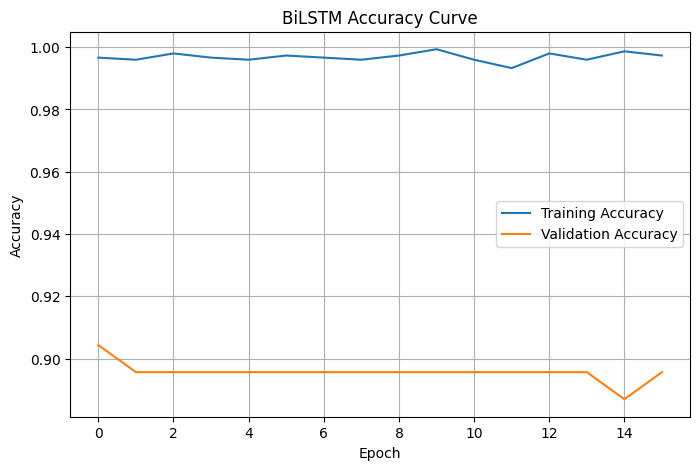

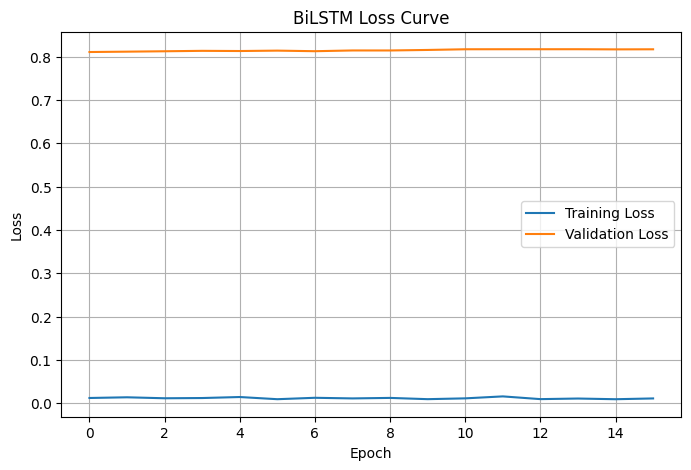

In [45]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history_bilstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_bilstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('BiLSTM Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history_bilstm.history['loss'], label='Training Loss')
plt.plot(history_bilstm.history['val_loss'], label='Validation Loss')
plt.title('BiLSTM Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [46]:
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff
import numpy as np

# Predictions
y_pred_prob = bilstm.predict(X_test)
# Convert predicted probabilities to class labels (index of the max probability)
y_pred_labels = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded y_test to class labels
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

fig = ff.create_annotated_heatmap(
    z=cm,
    x=CLASS_NAMES,
    y=CLASS_NAMES,
    colorscale='Blues'
)

fig.update_layout(
    title='BiLSTM Confusion Matrix',
    xaxis_title='Predicted Label',
    yaxis_title='True Label',
    width=700,
    height=600
)

fig.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


## **CNN-LSTM Model**

In [47]:
def cnnlstm_model():
    inp = Input(shape=(TIMESTEPS, F), name='input')
    x = tf.keras.layers.Conv1D(64,  3, padding='same', activation='relu')(inp)
    x = BatchNormalization()(x); x = Dropout(0.2)(x)
    x = tf.keras.layers.Conv1D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x); x = Dropout(0.2)(x)
    x = LSTM(64, return_sequences=False)(x)
    x = BatchNormalization()(x); x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x); x = Dropout(0.2)(x)
    out = Dense(N_CLASSES, activation='softmax')(x)
    return Model(inp, out, name='CNN_LSTM')

In [48]:
cnnlstm = cnnlstm_model()
cnnlstm.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
cnnlstm.summary()

Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 7, 77)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 7, 64)          │        14,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 7, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 7, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 7, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,339 (368.51 KB)

 Trainable params: 93,827 (366.51 KB)

 Non-trainable params: 512 (2.00 KB)

In [49]:
history_cnnlstm = cnnlstm.fit(
    X_train, y_train,
    validation_data=(X_val_raw.reshape(-1, TIMESTEPS, F), y_val),
    epochs=20, batch_size=32,
    callbacks=get_callbacks('best_cnnlstm.keras'), verbose=1)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.7105 - loss: 0.6605 - val_accuracy: 0.8609 - val_loss: 0.5956 - learning_rate: 0.0010
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8907 - loss: 0.3105 - val_accuracy: 0.8696 - val_loss: 0.4436 - learning_rate: 0.0010
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9318 - loss: 0.1950 - val_accuracy: 0.8783 - val_loss: 0.4303 - learning_rate: 0.0010
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9501 - loss: 0.1487 - val_accuracy: 0.8174 - val_loss: 0.4308 - learning_rate: 0.0010
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9676 - loss: 0.0978 - val_accuracy: 0.8435 - val_loss: 0.4297 - learning_rate: 0.0010
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9737 - loss: 0.0785 - val_accuracy: 0.8435 - val_loss: 0.5913 - learning_rate: 0.0010
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9791 - loss: 0.0745 - val_acc

In [50]:
y_pred_cnnlstm = np.argmax(cnnlstm.predict(X_test), axis=1)
print("=== CNN-LSTM Hybrid (Comparison) – Classification Report ===")
print(classification_report(np.argmax(y_test, axis=1), y_pred_cnnlstm,
                             target_names=CLASS_NAMES, digits=3))
_l, _a = cnnlstm.evaluate(X_test, y_test, verbose=0)
print(f"Test  →  Accuracy: {_a*100:.2f}%  |  Loss: {_l:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
=== CNN-LSTM Hybrid (Comparison) – Classification Report ===
              precision    recall  f1-score   support

        Fair      0.286     0.250     0.267         8
        Good      0.944     0.953     0.948       106
        Poor      0.000     0.000     0.000         1

    accuracy                          0.896       115
   macro avg      0.410     0.401     0.405       115
weighted avg      0.890     0.896     0.893       115

Test  →  Accuracy: 89.57%  |  Loss: 0.5114


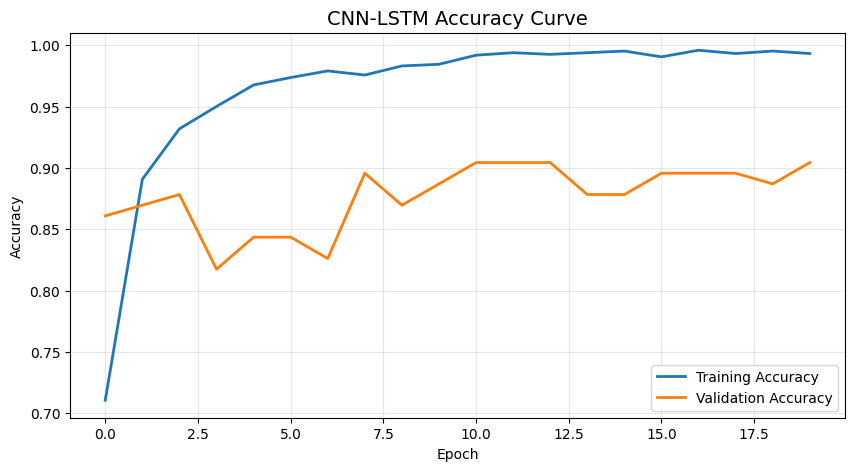

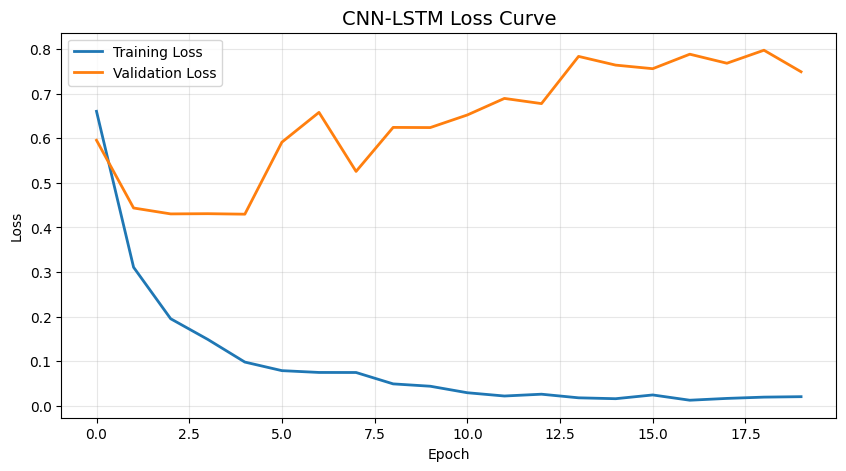

In [51]:
import matplotlib.pyplot as plt

# Accuracy Curve
plt.figure(figsize=(10,5))
plt.plot(history_cnnlstm.history['accuracy'],
         label='Training Accuracy',
         linewidth=2)

plt.plot(history_cnnlstm.history['val_accuracy'],
         label='Validation Accuracy',
         linewidth=2)

plt.title('CNN-LSTM Accuracy Curve', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


# Loss Curve
plt.figure(figsize=(10,5))
plt.plot(history_cnnlstm.history['loss'],
         label='Training Loss',
         linewidth=2)

plt.plot(history_cnnlstm.history['val_loss'],
         label='Validation Loss',
         linewidth=2)

plt.title('CNN-LSTM Loss Curve', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [53]:
Dense(N_CLASSES, activation='softmax')
import numpy as np

# Predict probabilities
y_pred_prob = cnnlstm.predict(X_test)

# Convert probabilities to class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot labels to class labels
y_true = np.argmax(y_test, axis=1)
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

cm = confusion_matrix(y_true, y_pred)

class_names = [f'Class {i}' for i in range(N_CLASSES)]

fig = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale='Blues',
    showscale=True
)

fig.update_layout(
    title='CNN-LSTM Confusion Matrix',
    xaxis_title='Predicted Label',
    yaxis_title='Actual Label',
    template='plotly_white',
    width=750,
    height=650
)

fig.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


## **Random Forest Model**

In [54]:
import numpy as np

# Flatten sequences (N, TIMESTEPS, F) → (N, TIMESTEPS*F)
X_train_ml = X_train.reshape(X_train.shape[0], -1)
X_test_ml  = X_test.reshape(X_test.shape[0], -1)

print(X_train_ml.shape)

(1482, 539)


In [55]:
y_train_cls = np.argmax(y_train, axis=1)
y_test_cls  = np.argmax(y_test, axis=1)

In [56]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train_ml, y_train_cls)

RandomForestClassifier(class_weight='balanced', max_depth=20, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [57]:
y_pred = rf.predict(X_test_ml)
y_prob = rf.predict_proba(X_test_ml)

In [58]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test_cls, y_pred))

print(classification_report(y_test_cls, y_pred))

Accuracy: 0.9391304347826087
              precision    recall  f1-score   support

           0       0.67      0.25      0.36         8
           1       0.95      1.00      0.97       106
           2       0.00      0.00      0.00         1

    accuracy                           0.94       115
   macro avg       0.54      0.42      0.45       115
weighted avg       0.92      0.94      0.92       115



In [59]:
from sklearn.metrics import confusion_matrix
import plotly.figure_factory as ff

cm = confusion_matrix(y_test_cls, y_pred)

class_names = [f"Class {i}" for i in np.unique(y_test_cls)]

fig = ff.create_annotated_heatmap(
    z=cm,
    x=class_names,
    y=class_names,
    colorscale="Blues"
)

fig.update_layout(
    title="Random Forest Confusion Matrix",
    xaxis_title="Predicted",
    yaxis_title="Actual",
    width=700,
    height=600
)

fig.show()

## **Results**

In [67]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# True labels
y_true = np.argmax(y_test, axis=1)

# Predictions
rf_pred = rf.predict(X_test_ml)

cnn_pred = np.argmax(cnnlstm.predict(X_test), axis=1)

bilstm_pred = np.argmax(bilstm.predict(X_test), axis=1)

# Store results
results = []

results.append([
    "Random Forest",
    accuracy_score(y_true, rf_pred),
    precision_score(y_true, rf_pred, average='weighted'),
    recall_score(y_true, rf_pred, average='weighted'),
    f1_score(y_true, rf_pred, average='weighted')
])

results.append([
    "CNN-LSTM",
    accuracy_score(y_true, cnn_pred),
    precision_score(y_true, cnn_pred, average='weighted'),
    recall_score(y_true, cnn_pred, average='weighted'),
    f1_score(y_true, cnn_pred, average='weighted')
])

results.append([
    "Bi-LSTM",
    accuracy_score(y_true, bilstm_pred),
    precision_score(y_true, bilstm_pred, average='weighted'),
    recall_score(y_true, bilstm_pred, average='weighted'),
    f1_score(y_true, bilstm_pred, average='weighted')
])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [68]:
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.939130,0.918737,0.939130,0.921667
1,CNN-LSTM,0.895652,0.889929,0.895652,0.892688
2,Bi-LSTM,0.913043,0.908481,0.913043,0.910618


In [70]:
import plotly.express as px

# Grouped bar chart (all metrics)
fig = px.bar(
    results_df,
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score"],
    barmode="group",
    text_auto=".3f",
    title="Comparative Performance of Models"
)

fig.update_layout(
    template="plotly_white",
    height=600,
    width=1000
)

fig.show()

In [71]:
# Accuracy-only chart (clean view)
fig2 = px.bar(
    results_df,
    x="Model",
    y="Accuracy",
    text_auto=".3f",
    color="Model",
    title="Model Accuracy Comparison"
)

fig2.update_layout(
    template="plotly_white",
    height=500
)

fig2.show()